# 🌍 Multi-Pest Spatio-Temporal Modeling Pipeline

### **Goal**
The previous analysis focused on a single view (or aggregated view). In this notebook, we will **automatically loop through the top pests** and build a dedicated Spatio-Temporal XGBoost model for each one.

### **Strategy & Aggregation Logic**
To do this correctly, we must follow these aggregation rules:

1.  **❌ Do NOT sum all pests together:** An outbreak of Aphids is different from an outbreak of Whiteflies. They respond to weather differently.
2.  **✅ Group by Pest:** We will filter the dataset for one pest at a time (e.g., just "Aphid").
3.  **✅ Group by District & Month:** For that specific pest, we sum the counts per district per month to match the weather data frequency.
4.  **✅ Fill Zeros:** If a district has no record of that pest in a specific month, it counts as `0` (no outbreak), which is vital for the model to learn "safe" conditions.

### **Pipeline Steps**
1.  Load Data (Pests + Weather).
2.  Identify Top Pests (by volume).
3.  **Loop through each Pest:**
    *   Filter data.
    *   Merge with Weather.
    *   Create Spatial Lags (Specific to that pest).
    *   Train Balanced XGBoost Model.
    *   Save Metrics.
4.  Compare results.

In [1]:
# ==========================================
# 1️⃣ IMPORTS & CONFIGURATION
# ==========================================
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuration
PEST_FILE = "merged_output.csv"
WEATHER_FILE = "monthly_weather_all_districts.csv"
TOP_N_PESTS = 4  # Analyze top 5 pests

In [2]:
# ==========================================
# 2️⃣ DATA LOADING HELPER
# ==========================================
def load_and_prep_data():
    print("Loading data...")
    weather_df = pd.read_csv(WEATHER_FILE)
    pest_df = pd.read_csv(PEST_FILE)

    # 1. Handle Date in Pest Data
    if "date" in pest_df.columns:
        date_col = "date"
    elif "CreatedOn" in pest_df.columns:
        date_col = "CreatedOn"
    else:
        date_col = pest_df.columns[pest_df.columns.str.lower().str.contains("date")][0]
    
    pest_df[date_col] = pd.to_datetime(pest_df[date_col], errors='coerce')
    pest_df["year_month"] = pest_df[date_col].dt.to_period("M")

    # 2. Handle Date in Weather Data
    weather_df["year_month"] = pd.PeriodIndex(weather_df["year_month"], freq="M")
    
    return pest_df, weather_df

pest_df, weather_df = load_and_prep_data()
print(f"Loaded {len(pest_df)} pest records and {len(weather_df)} weather records.")

Loading data...
Loaded 460899 pest records and 30951 weather records.


In [3]:
# ==========================================
# 3️⃣ IDENTIFY TOP PESTS
# ==========================================
# We only want to model pests that have enough data
pest_counts = pest_df["Pest"].value_counts()
top_pests = pest_counts.head(TOP_N_PESTS).index.tolist()

print(f"🔬 We will build models for: {top_pests}")
print("\nRecord counts:")
print(pest_counts.head(TOP_N_PESTS))

🔬 We will build models for: ['insect', 'fruit&shootborer', 'caterpiller', 'aphid']

Record counts:
Pest
insect              62196
fruit&shootborer    46067
caterpiller         45731
aphid               42500
Name: count, dtype: int64


In [4]:
# ==========================================
# 4️⃣ CORE FUNCTION: BUILD DATASET FOR ONE PEST
# ==========================================
def build_pest_dataset(pest_name, pest_df, weather_df):
    print(f"\n--- Processing: {pest_name} ---")
    
    # A. Filter for specific pest
    # Note: Case insensitive check is safer
    subset = pest_df[pest_df["Pest"].astype(str).str.lower() == pest_name.lower()].copy()
    
    # B. Aggregate: District + Month (Sum of pest counts)
    monthly_pest = (
        subset.groupby(["district", "year_month"])
        .agg({
            "pest_count": "sum",
            "latitude": "first",   # Keep coords
            "longitude": "first"
        })
        .reset_index()
    )
    
    # C. Merge with Weather
    merged = monthly_pest.merge(
        weather_df,
        on=["district", "year_month"],
        how="left"
    )
    
    # D. Create Full Panel (Fill Zeros for missing months)
    districts = merged["district"].unique()
    months = merged["year_month"].unique()
    
    full_index = pd.MultiIndex.from_product([districts, months], names=["district", "year_month"])
    full_df = merged.set_index(["district", "year_month"]).reindex(full_index).reset_index()
    
    # Fill Missing Pest Counts with 0 (No outbreak reported)
    full_df["pest_count"] = full_df["pest_count"].fillna(0)
    
    # Fill Missing Weather/Coords (Forward Fill then Back Fill)
    cols_to_fill = ["temp", "rainfall", "humidity", "wind", "latitude", "longitude"]
    full_df[cols_to_fill] = full_df.groupby("district")[cols_to_fill].transform(lambda x: x.ffill().bfill())
    
    # E. Define Severity (0, 1, 2) based on THIS pest's distribution
    # We use quantiles specific to this pest, because 100 Aphids might be "Low" but 100 Bollworms might be "High"
    q1 = full_df.groupby("district")["pest_count"].transform(lambda x: x.quantile(0.60)) # Higher threshold for 0s
    q2 = full_df.groupby("district")["pest_count"].transform(lambda x: x.quantile(0.85))
    
    full_df["severity"] = 0
    full_df.loc[full_df["pest_count"] > q1, "severity"] = 1
    full_df.loc[full_df["pest_count"] > q2, "severity"] = 2
    
    return full_df.sort_values(["district", "year_month"]).reset_index(drop=True)

In [5]:
# ==========================================
# 5️⃣ CORE FUNCTION: FEATURE ENGINEERING
# ==========================================
def add_features(df):
    # Temporal Lags
    df["month"] = df["year_month"].dt.month
    df["lag1"] = df.groupby("district")["pest_count"].shift(1)
    df["lag2"] = df.groupby("district")["pest_count"].shift(2)
    df["rolling_mean_3"] = df.groupby("district")["pest_count"].rolling(3).mean().reset_index(level=0, drop=True)
    
    # Weather Lags
    for col in ["temp", "rainfall", "humidity", "wind"]:
        df[f"{col}_lag1"] = df.groupby("district")[col].shift(1)
        
    return df

In [6]:
# ==========================================
# 6️⃣ CORE FUNCTION: SPATIAL LAG
# ==========================================
def add_spatial_lag(df):
    # Simplified Spatial Logic for speed in loop
    
    # 1. Get unique coords
    coords_df = df[["district", "latitude", "longitude"]].drop_duplicates().dropna()
    
    # 2. Build Adjacency (Distance < 150km)
    from sklearn.neighbors import NearestNeighbors
    coords = np.radians(coords_df[["latitude", "longitude"]].values)
    
    # Radius of earth = 6371km. 150km / 6371 = radians
    radius_rad = 200 / 6371.0 
    
    nn = NearestNeighbors(radius=radius_rad, metric='haversine')
    nn.fit(coords)
    adj_matrix = nn.radius_neighbors_graph(coords, mode='connectivity').toarray()
    np.fill_diagonal(adj_matrix, 0) # No self-loops
    
    # 3. Map District -> Index
    dist_to_idx = {d: i for i, d in enumerate(coords_df["district"])}
    
    # 4. Calculate Spatial Lag
    # "Average severity of neighbors in the PREVIOUS month"
    
    df["severity_lag1"] = df.groupby("district")["severity"].shift(1)
    
    spatial_lags = []
    
    # Pre-compute a lookup dictionary for speed: (year_month) -> {district: severity_lag1}
    lookup = df.set_index(["year_month", "district"])["severity_lag1"].to_dict()
    
    for idx, row in df.iterrows():
        ym = row["year_month"]
        d = row["district"]
        
        if d not in dist_to_idx:
            spatial_lags.append(0)
            continue
            
        d_idx = dist_to_idx[d]
        neighbor_indices = np.where(adj_matrix[d_idx] == 1)[0]
        
        if len(neighbor_indices) == 0:
            spatial_lags.append(0)
            continue
            
        neighbor_names = [coords_df.iloc[i]["district"] for i in neighbor_indices]
        
        # Get values from lookup
        vals = [lookup.get((ym, n_name), 0) for n_name in neighbor_names]
        
        # Filter out NaNs if any passed through
        vals = [v for v in vals if not np.isnan(v)]
        
        spatial_lags.append(np.mean(vals) if vals else 0)
        
    df["spatial_lag"] = spatial_lags
    return df.dropna()

In [7]:
# ==========================================
# 7️⃣ CORE FUNCTION: TRAIN & EVALUATE
# ==========================================
def train_pest_model(pest_name):
    # 1. Build
    df = build_pest_dataset(pest_name, pest_df, weather_df)
    
    # 2. Features
    df = add_features(df)
    
    # 3. Spatial
    df = add_spatial_lag(df)
    
    # 4. Split
    feature_cols = [
        "lag1", "lag2", "rolling_mean_3", "month", "spatial_lag",
        "temp_lag1", "rainfall_lag1", "humidity_lag1", "wind_lag1", 
        "temp", "rainfall", "humidity", "wind"
    ]
    
    train_df = df[df["year_month"] < df["year_month"].unique()[-12]]
    test_df = df[df["year_month"] >= df["year_month"].unique()[-12]]
    
    X_train = train_df[feature_cols]
    y_train = train_df["severity"]
    X_test = test_df[feature_cols]
    y_test = test_df["severity"]
    
    # 5. Train (Balanced XGBoost)
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=200,
        max_depth=4,           # Balanced depth
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,         # Regularization
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # 6. Evaluate
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"✅ {pest_name} Model Complete. Test Accuracy: {acc:.2%}")
    
    return {
        "Pest": pest_name,
        "Accuracy": acc,
        "Model": model,
        "Data": (X_test, y_test)
    }


--- Processing: insect ---
✅ insect Model Complete. Test Accuracy: 83.21%

--- Processing: fruit&shootborer ---
✅ fruit&shootborer Model Complete. Test Accuracy: 85.90%

--- Processing: caterpiller ---
✅ caterpiller Model Complete. Test Accuracy: 84.27%

--- Processing: aphid ---
✅ aphid Model Complete. Test Accuracy: 83.22%

🏆 FINAL RESULTS ACROSS ALL PESTS 🏆
               Pest  Accuracy
0            insect  0.832118
1  fruit&shootborer  0.858987
2       caterpiller  0.842667
3             aphid  0.832187


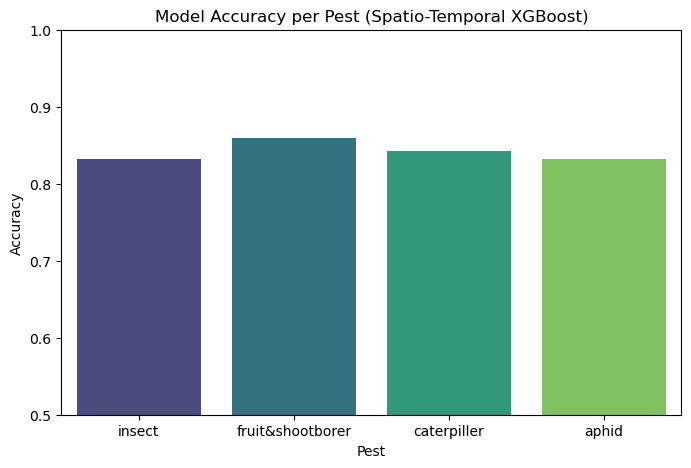

In [8]:
# ==========================================
# 8️⃣ 🚀 RUN THE LOOP
# ==========================================
results = []

for pest in top_pests:
    res = train_pest_model(pest)
    results.append(res)
    
# Summary DataFrame
summary_df = pd.DataFrame(results)[["Pest", "Accuracy"]]
print("\n🏆 FINAL RESULTS ACROSS ALL PESTS 🏆")
print(summary_df)

# Plot Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=summary_df, x="Pest", y="Accuracy", palette="viridis")
plt.ylim(0.5, 1.0)
plt.title("Model Accuracy per Pest (Spatio-Temporal XGBoost)")
plt.show()

# ==========================================
# 9️⃣ VISUALIZATION: ACTUAL vs PREDICTED
# ==========================================
Visualize the model's performance over time (Training vs Test period).
We calculate the **Average Severity** across all districts for each month.
*   **Solid Line:** Model Prediction (Risk Score).
*   **Dashed Line:** Actual Severity.
*   **Shaded Region:** 95% Confidence Interval (Spatial variation across districts).

📊 Generating Plot for: insect

--- Processing: insect ---


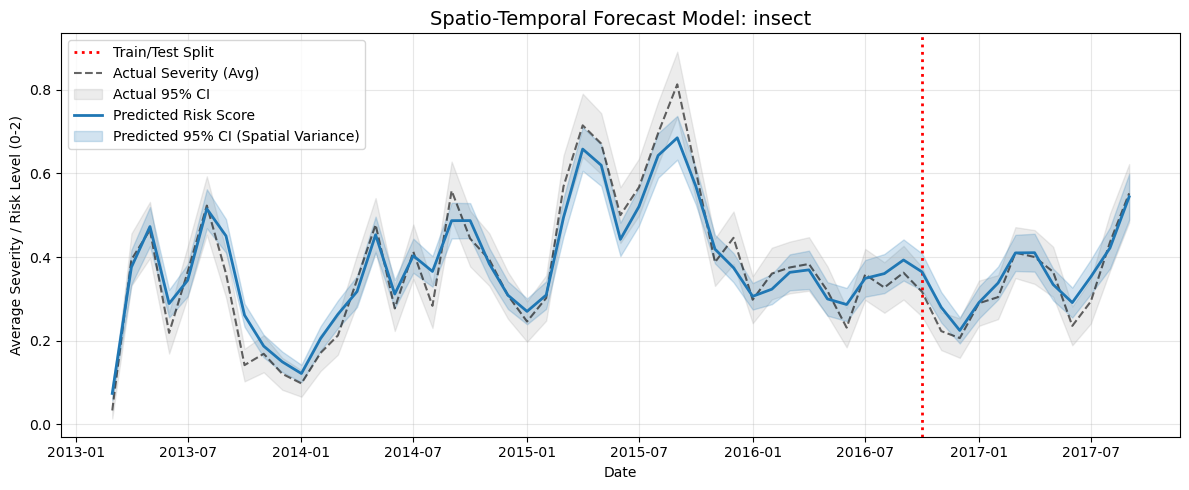

📊 Generating Plot for: fruit&shootborer

--- Processing: fruit&shootborer ---


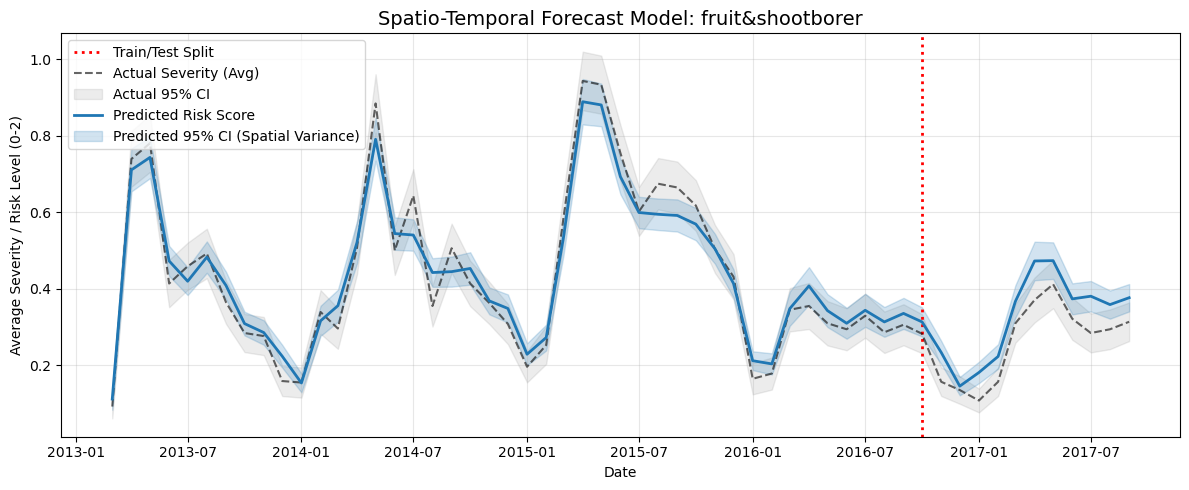

📊 Generating Plot for: caterpiller

--- Processing: caterpiller ---


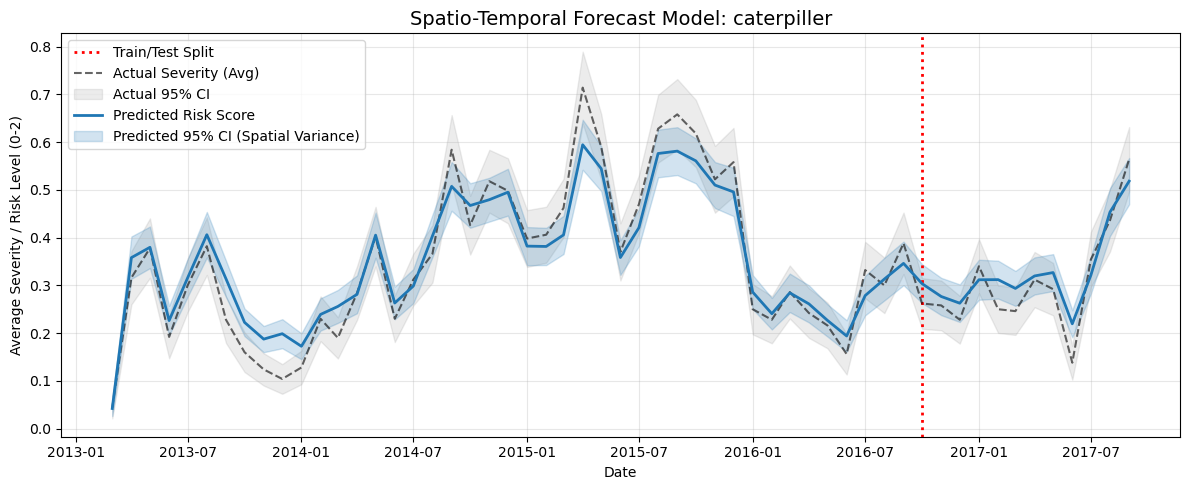

📊 Generating Plot for: aphid

--- Processing: aphid ---


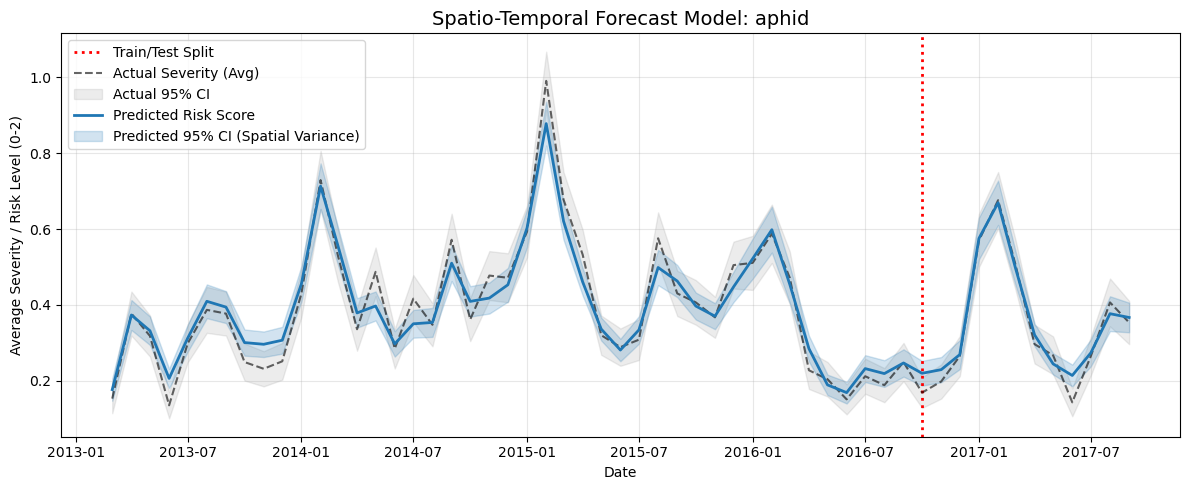

In [9]:
# ==========================================
# 🔟 PLOT FUNCTION: FORECAST WITH CONFIDENCE INTERVALS
# ==========================================
def plot_pest_forecast(pest_name, model):
    print(f"📊 Generating Plot for: {pest_name}")
    
    # 1. Re-create full Dataset for timeline
    # Reuse valid functions to get features
    df = build_pest_dataset(pest_name, pest_df, weather_df)
    df = add_features(df)
    df = add_spatial_lag(df)
    
    # 2. Features used in training (Must match exactly)
    feature_cols = [
        "lag1", "lag2", "rolling_mean_3", "month", "spatial_lag",
        "temp_lag1", "rainfall_lag1", "humidity_lag1", "wind_lag1", 
        "temp", "rainfall", "humidity", "wind"
    ]
    
    # 3. Predict Probabilities (Risk Score)
    # Expected Severity = 0*Prob(0) + 1*Prob(1) + 2*Prob(2)
    # This gives a continuous "Risk Score" suitable for averaging
    X_all = df[feature_cols].copy()
    probs = model.predict_proba(X_all)
    
    df["pred_risk"] = np.sum(probs * np.array([0, 1, 2]), axis=1)
    
    # 4. Aggregate: Weighted Mean per Month across all districts
    # Calculate Standard Error of Mean (sem) for Confidence Interval
    monthly = df.groupby("year_month").agg(
        obs_mean=("severity", "mean"),
        obs_sem=("severity", "sem"),
        pred_mean=("pred_risk", "mean"),
        pred_sem=("pred_risk", "sem")
    ).reset_index()
    
    monthly["date"] = monthly["year_month"].dt.to_timestamp()
    
    # Identify Split Point (Last 12 Months)
    split_date = monthly["date"].iloc[-12]
    
    # 5. Plot
    plt.figure(figsize=(12, 5))
    
    # Train / Test Separation
    plt.axvline(split_date, color="red", linestyle=":", linewidth=2, label="Train/Test Split")
    
    # Actuals
    plt.plot(monthly["date"], monthly["obs_mean"], color="black", linestyle="--", alpha=0.6, label="Actual Severity (Avg)")
    plt.fill_between(monthly["date"], 
                     monthly["obs_mean"] - 1.96 * monthly["obs_sem"], 
                     monthly["obs_mean"] + 1.96 * monthly["obs_sem"], 
                     color="gray", alpha=0.15, label="Actual 95% CI")
    
    # Forecast
    plt.plot(monthly["date"], monthly["pred_mean"], color="tab:blue", linewidth=2, label="Predicted Risk Score")
    plt.fill_between(monthly["date"], 
                     monthly["pred_mean"] - 1.96 * monthly["pred_sem"], 
                     monthly["pred_mean"] + 1.96 * monthly["pred_sem"], 
                     color="tab:blue", alpha=0.2, label="Predicted 95% CI (Spatial Variance)")
    
    plt.title(f"Spatio-Temporal Forecast Model: {pest_name}", fontsize=14)
    plt.ylabel("Average Severity / Risk Level (0-2)")
    plt.xlabel("Date")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run Visualization Loop
for res in results:
    plot_pest_forecast(res["Pest"], res["Model"])

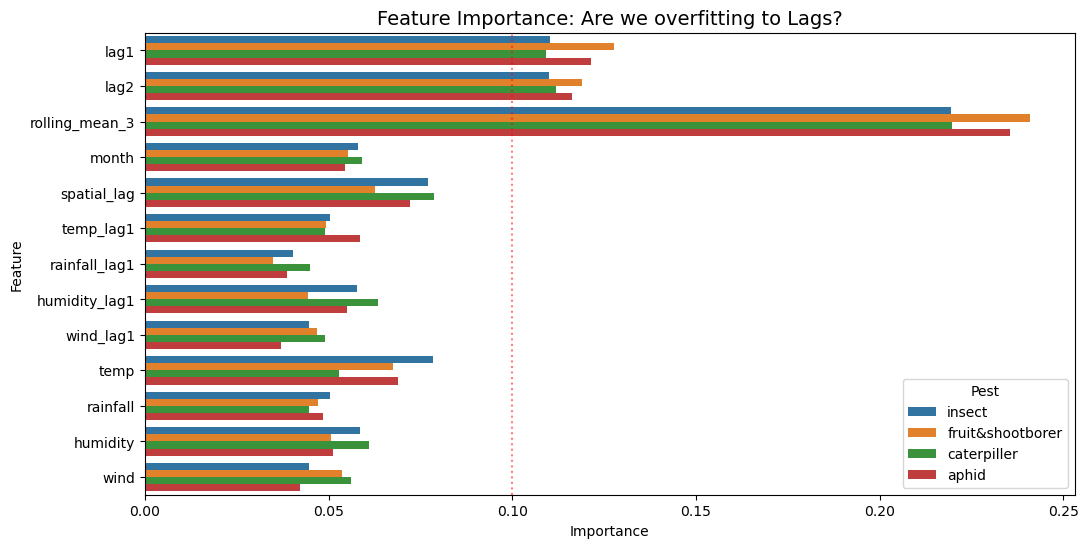

In [10]:
# ==========================================
# 1️⃣1️⃣ DIAGNOSIS: FEATURE IMPORTANCE
# ==========================================
# Check if the model is just memorizing 'Lag' (previous value) 
# instead of learning from 'Weather'.

def plot_feature_importance(results_list):
    feature_data = []
    
    for res in results_list:
        model = res["Model"]
        pest_name = res["Pest"]
        
        # Get importance dict
        importance = model.get_booster().get_score(importance_type='weight')
        
        # Normalize
        total = sum(importance.values())
        for feat, score in importance.items():
            feature_data.append({
                "Pest": pest_name,
                "Feature": feat,
                "Importance": score / total
            })
            
    # Convert to DF
    imp_df = pd.DataFrame(feature_data)
    
    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(data=imp_df, x="Importance", y="Feature", hue="Pest")
    plt.title("Feature Importance: Are we overfitting to Lags?", fontsize=14)
    plt.axvline(0.10, color="red", linestyle=":", alpha=0.5)
    plt.show()

plot_feature_importance(results)

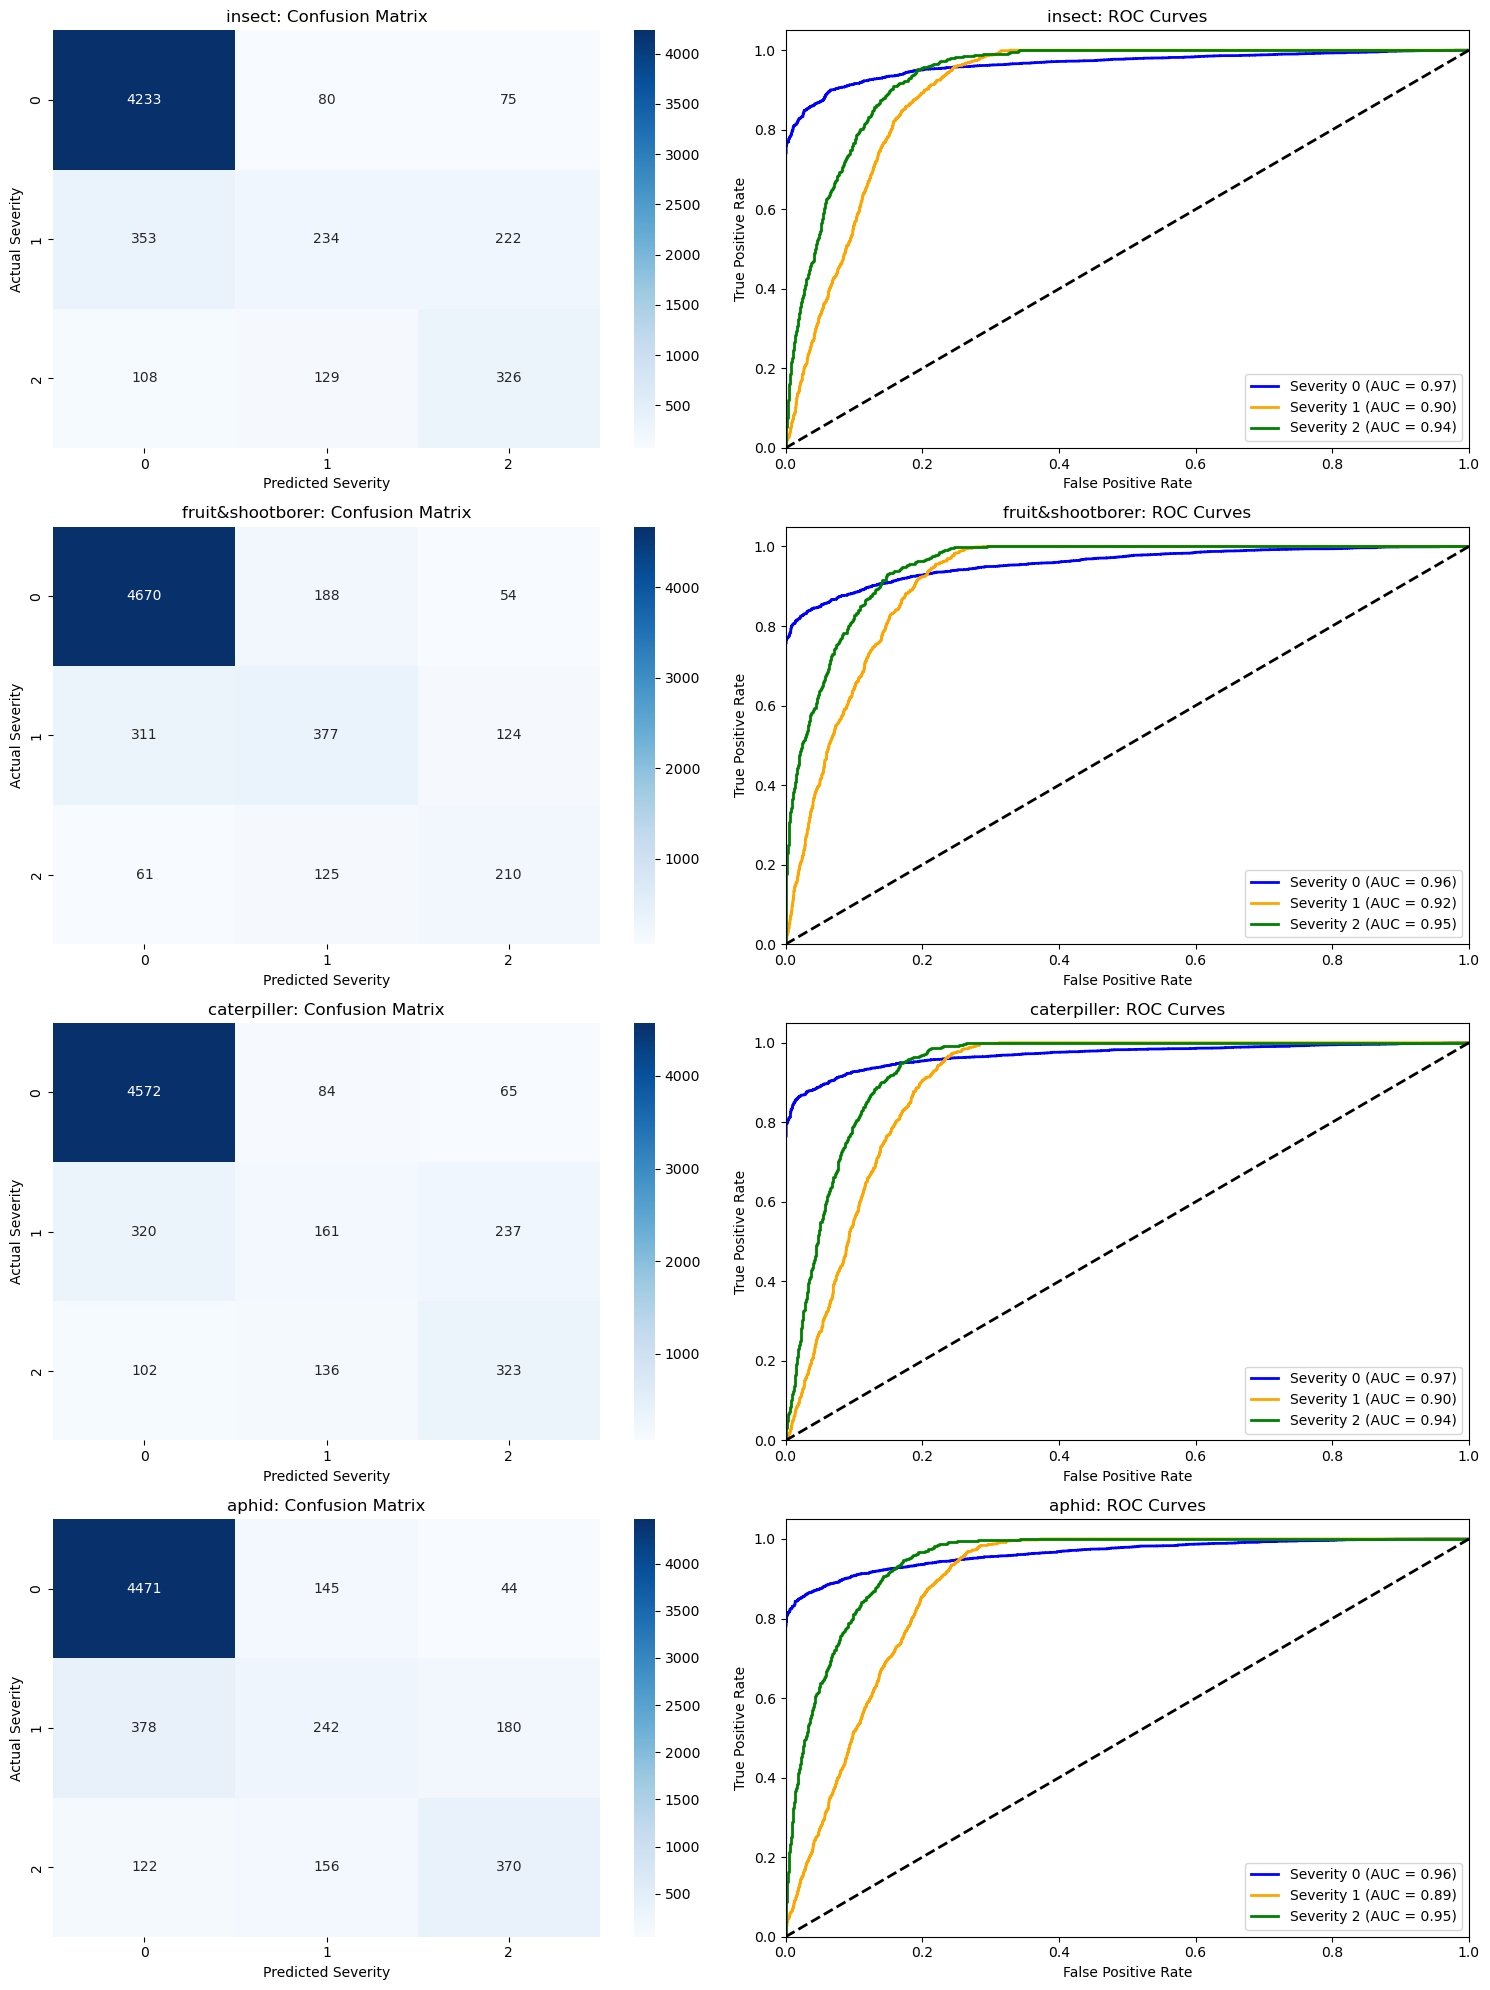

In [11]:
# ==========================================
# 1️⃣2️⃣ DETAILED EVALUATION: CONFUSION MATRICES & ROC
# ==========================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_detailed_metrics(results):
    fig, axes = plt.subplots(len(results), 2, figsize=(15, 5 * len(results)))
    
    for idx, res in enumerate(results):
        pest = res["Pest"]
        model = res["Model"]
        X_test, y_test = res["Data"]
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
        
        # 1. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0])
        axes[idx, 0].set_title(f"{pest}: Confusion Matrix")
        axes[idx, 0].set_ylabel("Actual Severity")
        axes[idx, 0].set_xlabel("Predicted Severity")
        
        # 2. ROC Curve (One-vs-Rest for Multiclass)
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        n_classes = 3
        
        colors = ['blue', 'orange', 'green']
        for i, color in zip(range(n_classes), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            axes[idx, 1].plot(fpr, tpr, color=color, lw=2,
                              label=f'Severity {i} (AUC = {roc_auc:.2f})')
        
        axes[idx, 1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[idx, 1].set_xlim([0.0, 1.0])
        axes[idx, 1].set_ylim([0.0, 1.05])
        axes[idx, 1].set_xlabel('False Positive Rate')
        axes[idx, 1].set_ylabel('True Positive Rate')
        axes[idx, 1].set_title(f"{pest}: ROC Curves")
        axes[idx, 1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_detailed_metrics(results)

In [12]:
# ==========================================
# 1️⃣3️⃣ FINAL METRICS SUMMARY (FOR PPT)
# ==========================================
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

evaluation_data = []

print("📍 GENERATING DETAILED EVALUATION METRICS...\n")

for res in results:
    pest_name = res["Pest"]
    model = res["Model"]
    
    # Unpack Data
    if "Data" in res:
         X_test, y_test = res["Data"]
    else:
        print(f"⚠️ Warning: Test data not found for {pest_name}")
        continue
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # Calculate Scalar Metrics (Weighted Average for Multiclass)
    metrics = {
        "Pest": pest_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    }
    evaluation_data.append(metrics)
    
    # Print Classification Report (Text format for copying)
    print(f"📋 Classification Report: {pest_name.upper()}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 60 + "\n")

# Create Summary DataFrame
metrics_df = pd.DataFrame(evaluation_data)

# Formatting for Display
print("\n📊 SUMMARY TABLE (COPY FOR PPT):")
# Round for cleaner display
display(metrics_df.round(4))

# Optional: Save to CSV for easy copy-pasting
metrics_df.to_csv("final_evaluation_metrics.csv", index=False)
print("✅ Metrics saved to 'final_evaluation_metrics.csv'")

📍 GENERATING DETAILED EVALUATION METRICS...

📋 Classification Report: INSECT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4388
           1       0.53      0.29      0.37       809
           2       0.52      0.58      0.55       563

    accuracy                           0.83      5760
   macro avg       0.65      0.61      0.62      5760
weighted avg       0.81      0.83      0.82      5760


📋 Classification Report: FRUIT&SHOOTBORER
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4912
           1       0.55      0.46      0.50       812
           2       0.54      0.53      0.54       396

    accuracy                           0.86      6120
   macro avg       0.67      0.65      0.66      6120
weighted avg       0.85      0.86      0.85      61

,Pest,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,insect,0.8321,0.8123,0.8321,0.8164,0.9534
1,fruit&shootborer,0.8590,0.8509,0.8590,0.8544,0.9516
2,caterpiller,0.8427,0.8192,0.8427,0.8266,0.9583
3,aphid,0.8322,0.8107,0.8322,0.8188,0.9525


✅ Metrics saved to 'final_evaluation_metrics.csv'
